In [9]:
import pandas as pd
import numpy as np

# ---------------------------------
# 1. Load datasets
# ---------------------------------
train_users = pd.read_csv("./data/train_users.csv")
test_users = pd.read_csv("./data/test_users.csv")

# ---------------------------------
# 2. Define columns
# ---------------------------------
TARGET_COL = "label"
ID_COLS = ["user_id"]

# Drop identifier columns safely
train_users = train_users.drop(columns=ID_COLS, errors="ignore")
test_users = test_users.drop(columns=ID_COLS, errors="ignore")

# Feature columns
feature_cols = [col for col in train_users.columns if col != TARGET_COL]

# ---------------------------------
# 3. Identify column types
# ---------------------------------
num_cols = train_users[feature_cols].select_dtypes(include=["int64", "float64"]).columns
cat_cols = train_users[feature_cols].select_dtypes(include=["object", "string"]).columns

print(f"Numerical features: {len(num_cols)}")
print(f"Categorical features: {list(cat_cols)}")

# ---------------------------------
# 4. Handle missing values
# ---------------------------------
# Numerical → median (train only)
for col in num_cols:
    median_val = train_users[col].median()
    train_users[col] = train_users[col].fillna(median_val)
    test_users[col] = test_users[col].fillna(median_val)

# Categorical → mode (train only)
for col in cat_cols:
    mode_val = train_users[col].mode()[0]
    train_users[col] = train_users[col].fillna(mode_val)
    test_users[col] = test_users[col].fillna(mode_val)

# ---------------------------------
# 5. Encode categorical features
# ---------------------------------
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

train_users[cat_cols] = encoder.fit_transform(train_users[cat_cols])
test_users[cat_cols] = encoder.transform(test_users[cat_cols])

# ---------------------------------
# 6. Sanity checks
# ---------------------------------
print("Missing values (train):", train_users[feature_cols].isnull().sum().sum())
print("Missing values (test):", test_users[feature_cols].isnull().sum().sum())

# ---------------------------------
# 7. Split features and target
# ---------------------------------
X = train_users[feature_cols]
y = train_users[TARGET_COL]
X_test = test_users[feature_cols]

# ---------------------------------
# 8. Encode target labels
# ---------------------------------
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ---------------------------------
# 9. Train–Validation Split (80/20)
# ---------------------------------
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ---------------------------------
# 10. Pipeline: Scaling + Logistic Regression
# ---------------------------------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

pipeline.fit(X_train, y_train)

# ---------------------------------
# 11. Evaluate on Validation Set
# ---------------------------------
from sklearn.metrics import classification_report

y_val_pred = pipeline.predict(X_val)

print("\nValidation Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=label_encoder.classes_
    )
)

# ---------------------------------
# 12. Context Detection on Test Users
# ---------------------------------
test_predictions = pipeline.predict(X_test)
test_user_labels = label_encoder.inverse_transform(test_predictions)

test_users_with_context = test_users.copy()
test_users_with_context["predicted_user_type"] = test_user_labels

print("\nSample Context Predictions:")
print(test_users_with_context.head())


Numerical features: 28
Categorical features: ['browser_version', 'region_code']
Missing values (train): 0
Missing values (test): 0

Validation Classification Report:
              precision    recall  f1-score   support

      user_1       0.85      0.80      0.82       142
      user_2       0.91      0.82      0.86       142
      user_3       0.71      0.85      0.78       116

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.83      0.82      0.82       400


Sample Context Predictions:
    age  income  clicks  purchase_amount  session_duration  content_variety  \
0  36.0   10000       4           500.00              2.54          0.47162   
1  33.0   19607       8          1906.81             39.74          0.55219   
2  51.0   21049      11           500.00             46.07          0.69961   
3  58.0   25752      13           500.00             60.86          0.86843   
4  32.0   25302      12      

In [10]:
# ============================================
# Alternative Classifier: Decision Tree
# ============================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Initialize Decision Tree
dt_clf = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

# Train model
dt_clf.fit(X_train, y_train)

# Validate model
y_val_pred_dt = dt_clf.predict(X_val)

print("Decision Tree Validation Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_dt,
        target_names=label_encoder.classes_
    )
)

# Context Detection on Test Users
test_predictions_dt = dt_clf.predict(X_test)
test_user_labels_dt = label_encoder.inverse_transform(test_predictions_dt)

test_users_with_context_dt = test_users.copy()
test_users_with_context_dt["predicted_user_type"] = test_user_labels_dt

print("\nSample Decision Tree Context Predictions:")
print(test_users_with_context_dt.head())


Decision Tree Validation Classification Report:
              precision    recall  f1-score   support

      user_1       0.81      0.86      0.83       142
      user_2       0.98      0.86      0.92       142
      user_3       0.80      0.86      0.83       116

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.87      0.86      0.86       400


Sample Decision Tree Context Predictions:
    age  income  clicks  purchase_amount  session_duration  content_variety  \
0  36.0   10000       4           500.00              2.54          0.47162   
1  33.0   19607       8          1906.81             39.74          0.55219   
2  51.0   21049      11           500.00             46.07          0.69961   
3  58.0   25752      13           500.00             60.86          0.86843   
4  32.0   25302      12          2693.22             39.77          0.81805   

   engagement_score  num_transactions  avg_monthly_sp

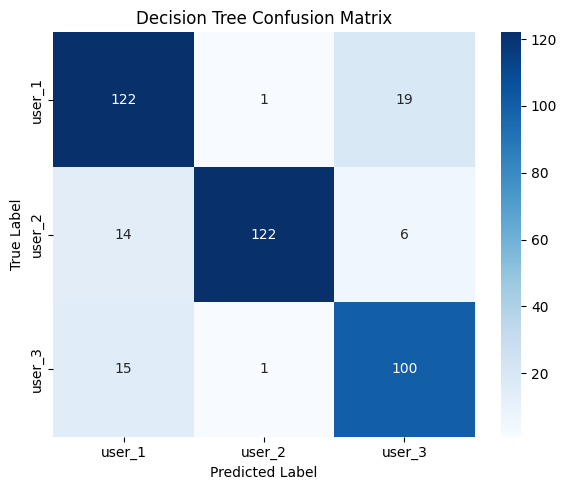

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_val_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()
